In this task, you will build 2 models to perform binary classification task.

Task: Arabic (Iraqi dialect) sentiemnt classification.

Data: https://www.kaggle.com/datasets/husseinnassrullah/arabic-iraqi-dialect-text-classification-dataset

Models: logistisc regression and FFNN.

# **Dataset**

In [4]:
!pip install gensim
import os, warnings, re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import gensim
from gensim.models import Word2Vec, KeyedVectors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.3 MB/s eta 0:00:00


In [20]:
import kagglehub
import os # Ensure os is imported for path manipulation
import pandas as pd # Ensure pandas is imported

path = kagglehub.dataset_download("husseinnassrullah/arabic-iraqi-dialect-text-classification-dataset")

# Construct the path to the data directory
data_dir = os.path.join(path, 'Arabic text classification dataset')

# Load positive reviews
positive_path = os.path.join(data_dir, 'positive reviews.txt')
with open(positive_path, 'r', encoding='utf-8') as f:
    positive_reviews = f.readlines()
df_positive = pd.DataFrame([review.strip() for review in positive_reviews], columns=['text'])
df_positive['label'] = 'positive'

# Load negative reviews
negative_path = os.path.join(data_dir, 'negative reviews.txt')
with open(negative_path, 'r', encoding='utf-8') as f:
    negative_reviews = f.readlines()
df_negative = pd.DataFrame([review.strip() for review in negative_reviews], columns=['text'])
df_negative['label'] = 'negative'

# Concatenate into a single DataFrame
df = pd.concat([df_positive, df_negative], ignore_index=True)

print('Shape:', df.shape)
print(df.head())
print('\nLabel distribution:')
print(df.iloc[:, -1].value_counts())

Using Colab cache for faster access to the 'arabic-iraqi-dialect-text-classification-dataset' dataset.
Shape: (1201, 2)
                                                text     label
0                                          Citation:  positive
1  This dataset was generated for the study prese...  positive
2  "Hussein A. Nasrullah, Mohammed A. Nasrullah, ...  positive
3  Sentiment analysis in arabic language using ma...  positive
4  AIP Conf. Proc. 27 March 2023; 2651 (1): 06001...  positive

Label distribution:
label
positive    677
negative    524
Name: count, dtype: int64


In [21]:
TEXT_COL  = df.columns[0]   # first column = text
LABEL_COL = df.columns[-1]  # last  column = label

def clean_arabic(text: str) -> str:
    """Basic Arabic text cleaning."""
    text = str(text)
    text = re.sub(r'[^؀-ۿ\s]', ' ', text)   # keep Arabic chars only
    text = re.sub(r'(.)\1{2,}', r'\1', text)           # collapse repeated chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df[TEXT_COL].apply(clean_arabic)

# Encode labels (negative→0, positive→1)
label_map = {'negative': 0, 'positive': 1}
print('Label mapping:', label_map)
df['label'] = df[LABEL_COL].map(label_map)

# Train / test split  (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Label mapping: {'negative': 0, 'positive': 1}
Train: 960 | Test: 241


# Q1: Build a logistic regression model with TF-IDF as the text representation technique.

In [22]:
# TF-IDF Vectoriser
tfidf = TfidfVectorizer(
    analyzer='char_wb',   # character n-grams work well for Arabic dialects
    ngram_range=(2, 4),
    max_features=30_000,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print('TF-IDF matrix shape:', X_train_tfidf.shape)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='weighted')

print('\n=== Logistic Regression + TF-IDF ===')
print(f'Accuracy : {acc_lr:.4f}')
print(f'F1 Score : {f1_lr:.4f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred_lr))

TF-IDF matrix shape: (960, 8570)

=== Logistic Regression + TF-IDF ===
Accuracy : 0.9170
F1 Score : 0.9164

Detailed Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       105
           1       0.90      0.96      0.93       136

    accuracy                           0.92       241
   macro avg       0.92      0.91      0.91       241
weighted avg       0.92      0.92      0.92       241



# Q2: Build a Feed Forward NN model with 2 hidden layers, each one with 10 units with TF-IDF as the text representation technique.

In [24]:
# Convert sparse TF-IDF matrices to dense numpy arrays for Keras
X_train_dense = X_train_tfidf.toarray().astype('float32')
X_test_dense  = X_test_tfidf.toarray().astype('float32')
input_dim = X_train_dense.shape[1]

#Build FFNN
def build_ffnn(input_dim: int, hidden_units: int = 10) -> keras.Model:
    """Feed Forward Neural Network with 2 hidden layers."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        # Hidden layer 1
        layers.Dense(hidden_units, activation='relu'),
        layers.Dropout(0.3),
        # Hidden layer 2
        layers.Dense(hidden_units, activation='relu'),
        layers.Dropout(0.3),
        # Output layer (binary classification)
        layers.Dense(1, activation='sigmoid')
    ], name='FFNN')
    return model

ffnn_tfidf = build_ffnn(input_dim=input_dim, hidden_units=10)
ffnn_tfidf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
ffnn_tfidf.summary()

#  Train
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_tfidf = ffnn_tfidf.fit(
    X_train_dense, y_train.values,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
y_prob_ffnn_tfidf = ffnn_tfidf.predict(X_test_dense, verbose=0).ravel()
y_pred_ffnn_tfidf = (y_prob_ffnn_tfidf >= 0.5).astype(int)

acc_ffnn_tfidf = accuracy_score(y_test, y_pred_ffnn_tfidf)
f1_ffnn_tfidf  = f1_score(y_test, y_pred_ffnn_tfidf, average='weighted')

print('\n=== FFNN + TF-IDF ===')
print(f'Accuracy : {acc_ffnn_tfidf:.4f}')
print(f'F1 Score : {f1_ffnn_tfidf:.4f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred_ffnn_tfidf))

Model: "FFNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │        85,710 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,831 (335.28 KB)

 Trainable params: 85,831 (335.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5648 - loss: 0.6919 - val_accuracy: 0.5208 - val_loss: 0.6914
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5694 - loss: 0.6846 - val_accuracy: 0.5208 - val_loss: 0.6830
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6343 - loss: 0.6620 - val_accuracy: 0.5521 - val_loss: 0.6592
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7593 - loss: 0.6200 - val_accuracy: 0.7708 - val_loss: 0.6232
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8090 - loss: 0.5676 - val_accuracy: 0.8021 - val_loss: 0.5784
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8519 - loss: 0.4966 - val_accuracy: 0.8125 - val_loss: 0.5283
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8715 - loss: 0.4343 - val_accuracy: 0.8750 - val_loss: 0.4757
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8993 - loss: 0.3667 - val_accuracy: 0.8750 - v

# Q3: Build a Feed Forward NN model with 2 hidden layers, each one with 10 units with AraVec as the text representation technique.

In [34]:
ARAVEC_PATH = 'full_grams_cbow_100_twitter.mdl'
EMBED_DIM   = 100

In [39]:
path = kagglehub.dataset_download("hadeerkhalednabil/full-grams-cbow-100-twitter")

# List the contents of the downloaded directory to identify the correct model file name
print(f"Contents of {path}: {os.listdir(path)}")

# Construct the full path to the model file using the downloaded directory and the defined ARAVEC_PATH filename
full_aravec_model_path = os.path.join(path, ARAVEC_PATH)

# ── Load or train a fallback Word2Vec model if AraVec is unavailable ──────────
if os.path.exists(full_aravec_model_path):
    print('Loading AraVec …')
    aravec_model = gensim.models.Word2Vec.load(full_aravec_model_path)
    wv = aravec_model.wv
    # Update EMBED_DIM from the loaded model's vector size
    global EMBED_DIM
    EMBED_DIM = wv.vector_size
    print(f'AraVec loaded: {len(wv)} words, {wv.vector_size}-dim')
else:
    print(f'AraVec not found at specified path: {full_aravec_model_path}.')
    # If the user intends to train a fallback model, that logic needs to be re-added here.
    # For now, this will lead to a NameError in subsequent cells if wv or EMBED_DIM are used.


Using Colab cache for faster access to the 'full-grams-cbow-100-twitter' dataset.
Contents of /kaggle/input/full-grams-cbow-100-twitter: ['full_grams_cbow_100_twitter.mdl', 'full_grams_cbow_100_twitter.mdl.wv.vectors.npy', 'full_grams_cbow_100_twitter.mdl.trainables.syn1neg.npy']
Loading AraVec …
AraVec loaded: 1476715 words, 100-dim


In [40]:
# Sentence Representation via Mean Pooling
def text_to_vec(text: str, wv, dim: int = 100) -> np.ndarray:
    tokens = text.split()
    vecs   = [wv[tok] for tok in tokens if tok in wv]
    if vecs:
        return np.mean(vecs, axis=0).astype('float32')
    return np.zeros(dim, dtype='float32')

X_train_av = np.vstack([text_to_vec(t, wv, EMBED_DIM) for t in X_train])
X_test_av  = np.vstack([text_to_vec(t, wv, EMBED_DIM) for t in X_test])

print('AraVec feature matrix — Train:', X_train_av.shape, '| Test:', X_test_av.shape)

AraVec feature matrix — Train: (960, 100) | Test: (241, 100)


In [41]:
# Build & Train FFNN on AraVec features
ffnn_av = build_ffnn(input_dim=EMBED_DIM, hidden_units=10)
ffnn_av.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
ffnn_av.summary()

history_av = ffnn_av.fit(
    X_train_av, y_train.values,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
y_prob_ffnn_av = ffnn_av.predict(X_test_av, verbose=0).ravel()
y_pred_ffnn_av = (y_prob_ffnn_av >= 0.5).astype(int)

acc_ffnn_av = accuracy_score(y_test, y_pred_ffnn_av)
f1_ffnn_av  = f1_score(y_test, y_pred_ffnn_av, average='weighted')

print('\n=== FFNN + AraVec ===')
print(f'Accuracy : {acc_ffnn_av:.4f}')
print(f'F1 Score : {f1_ffnn_av:.4f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred_ffnn_av))

Model: "FFNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,131 (4.42 KB)

 Trainable params: 1,131 (4.42 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5521 - loss: 0.7741 - val_accuracy: 0.6250 - val_loss: 0.6250
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6273 - loss: 0.6457 - val_accuracy: 0.7500 - val_loss: 0.5752
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7083 - loss: 0.5878 - val_accuracy: 0.7396 - val_loss: 0.5447
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7407 - loss: 0.5427 - val_accuracy: 0.7500 - val_loss: 0.5175
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7338 - loss: 0.5401 - val_accuracy: 0.7500 - val_loss: 0.4916



=== FFNN + AraVec ===
Accuracy : 0.7344
F1 Score : 0.7309

Detailed Report:
              precision    recall  f1-score   support

           0       0.73      0.62      0.67       105
           1       0.74      0.82      0.78       136

    accuracy                           0.73       241
   macro avg       0.73      0.72      0.72       241
weighted avg       0.73      0.73      0.73       241



# Q4: Compare the accuracy and F1 score of the 3 models.

                              Accuracy  F1 Score (weighted)
Model                                                      
Logistic Regression + TF-IDF  0.917012             0.916409
FFNN (2×10) + TF-IDF          0.912863             0.912308
FFNN (2×10) + AraVec          0.734440             0.730866


/tmp/ipykernel_544/3209996258.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results.index, rotation=15, ha='right', fontsize=10)
/tmp/ipykernel_544/3209996258.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results.index, rotation=15, ha='right', fontsize=10)


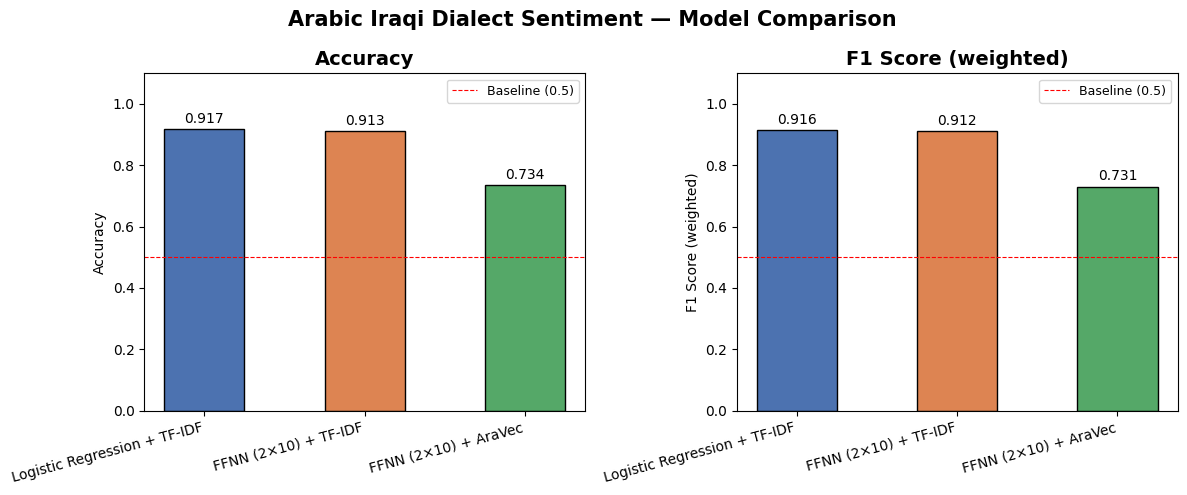

Chart saved → model_comparison.png


In [42]:
import matplotlib.pyplot as plt

#Summary Table
results = pd.DataFrame({
    'Model': [
        'Logistic Regression + TF-IDF',
        'FFNN (2×10) + TF-IDF',
        'FFNN (2×10) + AraVec'
    ],
    'Accuracy': [acc_lr, acc_ffnn_tfidf, acc_ffnn_av],
    'F1 Score (weighted)': [f1_lr, f1_ffnn_tfidf, f1_ffnn_av]
})
results = results.set_index('Model')
print(results.to_string())

# Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col in zip(axes, ['Accuracy', 'F1 Score (weighted)']):
    bars = ax.bar(results.index, results[col], color=colors, edgecolor='black', width=0.5)
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(results.index, rotation=15, ha='right', fontsize=10)
    ax.set_ylabel(col)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='Baseline (0.5)')
    ax.legend(fontsize=9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Arabic Iraqi Dialect Sentiment — Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → model_comparison.png')